<a href="https://colab.research.google.com/github/nico89h/Analisis-computacional-de-datos-de-microbioma-intestinal-mediante-grafos-y-aprendizaje-automatico/blob/main/taxonomia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis computacional de datos de microbioma intestinal mediante grafos y aprendizaje automático**


En este bloque se identificara a cada secuencia de ADN md5 con su respectiva taxonomia.

Se usaran dos archivos matriz_final.tsv ( Es la matriz de abundancia cruda de cada paciente, es decir, con los hash)

Luego, tenemos taxonomy.tsv, que corresponde al diccionario de cada hash md5# Nueva sección

In [176]:
import pandas as pd
import numpy as np

matriz= pd.read_csv('/content/drive/MyDrive/Tesis/desarrollo/matriz_final.tsv', sep = '\t', skiprows=1)
matriz= matriz.rename(columns={'#OTU ID': 'Feature ID'})
taxonomia = pd.read_csv('/content/drive/MyDrive/Tesis/desarrollo/taxonomy.tsv', sep='\t')
#tenemos que en matriz, cada una de las columnas son los pacientes, y las filas son los hash
#en taxonomia, tendremos: fila(hash) | taxonomia | confianza( de que sea esa bacteria)
# tenemos que los hash NO SE REPITEN, son UNICOS, no hay filas repetidas

#comienzo eliminando lo innecesario de la 3era columna ya que solo me importa el genero de la bacteria, no toda
#la informacion adicional

def extraer_nombre_bacteria(tax_string):
    # Si la celda está vacía o sin asignar
    if pd.isna(tax_string) or tax_string == 'Unassigned':
        return 'Desconocida'

    # Cortamos el string en una lista de niveles
    niveles = tax_string.split(';')

    # 1. EL FILTRO: Eliminamos por completo la especie ('s__') si es que existe
    niveles_sin_especie = [nivel for nivel in niveles if not nivel.strip().startswith('s__')]

    # 2. BÚSQUEDA: Recorremos lo que quedó de atrás para adelante
    for nivel in reversed(niveles_sin_especie):
        nivel_limpio = nivel.strip()

        # Buscamos el separador biológico
        if '__' in nivel_limpio:
            nombre_puro = nivel_limpio.split('__')[-1].strip()

            # Si el nivel no está vacío (ej. no es solo "g__"), lo retornamos
            if nombre_puro:
                return nombre_puro

    # Fallback de seguridad
    return 'Desconocida'


taxonomia['Bacteria_Limpia'] = taxonomia['Taxon'].apply(extraer_nombre_bacteria)

#luego hago un inner join, usando los hash

df_fusionado = pd.merge(taxonomia[['Feature ID', 'Bacteria_Limpia']], matriz, on='Feature ID', how='inner')

df_fusionado = df_fusionado.drop(columns=['Feature ID'])

# Agrupamos por el nombre de la bacteria y sumamos los valores numéricos de los pacientes
df_fase1 = df_fusionado.groupby('Bacteria_Limpia').sum().reset_index()

# Verificamos el resultado final
print("Dimensiones de la matriz agrupada:", df_fase1.shape)
print(df_fase1.head())
df_fase1.to_csv('/content/drive/MyDrive/Tesis/desarrollo/matriztotal.tsv', sep='\t', index=False)

Dimensiones de la matriz agrupada: (403, 122)
  Bacteria_Limpia  SRR10442269_1  SRR10442270_1  SRR10442271_1  SRR10442272_1  \
0           11-24            0.0            0.0            0.0            0.0   
1          4-29-1            0.0            0.0            0.0            0.0   
2              A2            0.0            0.0            0.0            0.0   
3  ADurb.Bin063-1            0.0            0.0            0.0            0.0   
4        AKAU4049            0.0            0.0            0.0            0.0   

   SRR10442273_1  SRR10442274_1  SRR10442275_1  SRR10442276_1  SRR10442277_1  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0      

**Se define la relacion de los nodos y se hace la Normalización Logarítmica (Log1p)**

In [177]:
# Se utilizara la funcion melt, para poder definir la relacion entre los nodos y el "peso" de la arista
# Se crea la tabla pivotante
# Se van a tener 3 columnas : Bacteria | Paciente | AbundanciaTaxonomica
# En esta etapa tmb se eliminan ceros
import numpy as np

df_fase1=df_fase1.melt(id_vars=['Bacteria_Limpia'], var_name='Paciente', value_name='AbundanciaTaxonomica')
#print(df_fase1)

#elimino los valores de 0.0
df_fase1.drop(df_fase1[df_fase1['AbundanciaTaxonomica'] == 0.0].index, inplace=True)


df_fase1['AbundanciaTaxonomica']= np.log1p(df_fase1['AbundanciaTaxonomica'])

# hare que cada paciente este con _1
df_fase1['Paciente'] = df_fase1['Paciente'].apply(lambda x: x if x.endswith('_1') else x + '_1')

# hare que cada paciente este con _1
df_fase1.to_csv('/content/drive/MyDrive/Tesis/desarrollo/columnasGrafo.tsv', sep='\t', index=False)


print(df_fase1)


                       Bacteria_Limpia       Paciente  AbundanciaTaxonomica
20                         Akkermansia  SRR10442269_1              1.098612
41                        Anaerostipes  SRR10442269_1              3.433987
56                         Bacteroides  SRR10442269_1              6.555357
60                     Bifidobacterium  SRR10442269_1              5.575949
63                             Blautia  SRR10442269_1              5.746203
...                                ...            ...                   ...
48754   [Eubacterium]_ventriosum_group  SRR10442395_1              3.367296
48756  [Ruminococcus]_gauvreauii_group  SRR10442395_1              5.257495
48757      [Ruminococcus]_gnavus_group  SRR10442395_1              7.505492
48758     [Ruminococcus]_torques_group  SRR10442395_1              8.117909
48762                       uncultured  SRR10442395_1              4.406719

[11261 rows x 3 columns]


**Construcción del Grafo Heterogéneo**

In [178]:
# Se configura los tensores (numeros de cada paciente y bacteria)
# como se usa pytorch, el mismo solo interpreta numeros
# se hace un diccionario de los pacientes y bacterias
# pacientes (1-126), bacterias (127-N)

pacientes = df_fase1.Paciente.unique()
diccionariopacientes= {nombre: indice for indice, nombre in enumerate(pacientes, start=1)}
print(diccionariopacientes)

bacterias = df_fase1.Bacteria_Limpia.unique()
diccionariobacterias= {nombre: indice for indice, nombre in enumerate(bacterias, start=127)}

pacientes= df_fase1.Paciente
bacterias= df_fase1.Bacteria_Limpia


df_fase1['paciente_id'] = pacientes.map(diccionariopacientes)
df_fase1['bacteria_id'] = bacterias.map(diccionariobacterias)

print(df_fase1)

len(df_fase1['Bacteria_Limpia'].unique())

{'SRR10442269_1': 1, 'SRR10442270_1': 2, 'SRR10442271_1': 3, 'SRR10442272_1': 4, 'SRR10442273_1': 5, 'SRR10442274_1': 6, 'SRR10442275_1': 7, 'SRR10442276_1': 8, 'SRR10442277_1': 9, 'SRR10442278_1': 10, 'SRR10442279_1': 11, 'SRR10442280_1': 12, 'SRR10442281_1': 13, 'SRR10442282_1': 14, 'SRR10442283_1': 15, 'SRR10442284_1': 16, 'SRR10442285_1': 17, 'SRR10442286_1': 18, 'SRR10442287_1': 19, 'SRR10442288_1': 20, 'SRR10442289_1': 21, 'SRR10442290_1': 22, 'SRR10442291_1': 23, 'SRR10442292_1': 24, 'SRR10442293_1': 25, 'SRR10442294_1': 26, 'SRR10442295_1': 27, 'SRR10442296_1': 28, 'SRR10442297_1': 29, 'SRR10442298_1': 30, 'SRR10442299_1': 31, 'SRR10442300_1': 32, 'SRR10442301_1': 33, 'SRR10442302_1': 34, 'SRR10442303_1': 35, 'SRR10442304_1': 36, 'SRR10442305_1': 37, 'SRR10442306_1': 38, 'SRR10442307_1': 39, 'SRR10442308_1': 40, 'SRR10442309_1': 41, 'SRR10442310_1': 42, 'SRR10442311_1': 43, 'SRR10442312_1': 44, 'SRR10442313_1': 45, 'SRR10442314_1': 46, 'SRR10442315_1': 47, 'SRR10442316_1': 48, 

403

En este paso, le asigno a cada paciente, su diagnostico respectivo

In [179]:
# comienzo filtrando los pacientes con su diagnostico
df_sra = pd.read_csv('/content/drive/MyDrive/Tesis/desarrollo/SraRunTable.csv')

# 2. Crear un DataFrame limpio con los nombres reales (agregando _1)
diagnosticos_corregidos = pd.DataFrame()
diagnosticos_corregidos['Paciente'] = df_sra['Run'] + '_1'

# 3. Asignar 'TEA' o 'HC' leyendo la columna original 'isolate'
diagnosticos_corregidos['Diagnosis'] = df_sra['isolate'].apply(
    lambda x: 'TEA' if 'ASD' in str(x) else 'HC'
)

ruta_tsv = '/content/drive/MyDrive/Tesis/desarrollo/diagnosticos_pacientes.tsv'
diagnosticos_corregidos.to_csv(ruta_tsv, sep='\t', index=False)

print("¡Archivo TSV generado")

¡Archivo TSV generado


In [180]:
diagnosticos= pd.read_csv('/content/drive/MyDrive/Tesis/desarrollo/diagnosticos_pacientes.tsv', sep='\t')
# a TEA se le asignara el 1 y al HC el 0
#basandome en esto, tenemos que:

diccionarioDiagnosticos= {
    'TEA': 1,
    'HC': 0
}
diagnosticos['Diagnosis'] = diagnosticos['Diagnosis'].map(diccionarioDiagnosticos)

#luego añado la columna de diagnosticos a df_fase1 basandome en los pacientes
# es decir se hace un inner join, por cada nombre de paciente

diagnosticos.rename(columns={'Patient Name': 'Paciente'}, inplace=True)

diagnosticos['Paciente'] = diagnosticos['Paciente'].str.strip()
df_fase1['Paciente'] = df_fase1['Paciente'].str.strip()

df_fase1['Diagnosticos'] = df_fase1['Paciente'].map(diagnosticos.set_index('Paciente')['Diagnosis'])
pacientes_con_nan = df_fase1[df_fase1['Diagnosticos'].isna()]['Paciente'].tolist()

print(f"Total de pacientes con NaN: {len(pacientes_con_nan)}")
print(f"Ejemplo de 5 pacientes con NaN: {pacientes_con_nan}")

pacientesTEA = df_fase1[df_fase1['Diagnosticos'] == 1]
pacientesHC = df_fase1[df_fase1['Diagnosticos'] == 0]

print(len(pacientesTEA['Paciente'].unique()))

print(len(pacientesHC['Paciente'].unique()))


Total de pacientes con NaN: 0
Ejemplo de 5 pacientes con NaN: []
71
50


En este paso se creara el grafo

In [181]:
!pip install torch_geometric

In [182]:
import torch
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import pandas as pd # Asegúrate de importar pandas

# 0. Mapeamos los IDs reales a IDs posicionales locales (de 0 a N-1)
df_fase1['paciente_id'] = pd.factorize(df_fase1['paciente_id'])[0]
df_fase1['bacteria_id'] = pd.factorize(df_fase1['bacteria_id'])[0]

#defino el grafo heterogeneo
data = HeteroData()

# Creamos las características iniciales 'x' de cada tipo de nodo (One-Hot Encoding)
num_pacientes = df_fase1['paciente_id'].max() + 1
num_bacterias = df_fase1['bacteria_id'].max() + 1

#defino una matriz cuadrada de cada uno
#matriz de paciente
data['paciente'].x = torch.eye(num_pacientes, dtype=torch.float)
#matriz de bacteria
data['bacteria'].x = torch.eye(num_bacterias, dtype=torch.float)

# 5. Definimos el tensor de conexiones (edge_index) entre ambos tipos de nodos
origen = torch.tensor(df_fase1['paciente_id'].values, dtype=torch.long)
destino = torch.tensor(df_fase1['bacteria_id'].values, dtype=torch.long)

# Stackeamos para obtener la estructura [2, num_conexiones]
data['paciente', 'abundancia_de', 'bacteria'].edge_index = torch.stack([origen, destino], dim=0)


# 1. Nos quedamos solo con las columnas de ID y Diagnóstico, y borramos los duplicados
df_etiquetas = df_fase1[['paciente_id', 'Diagnosticos']].drop_duplicates()

# 2. ORDENAMOS estrictamente por el paciente_id (0 al N) para que coincida con los nodos
df_etiquetas = df_etiquetas.sort_values('paciente_id')

# 3. Ahora sí, extraemos la columna ordenada como tensor (tendrá tamaño 127)
data['paciente'].y = torch.tensor(df_etiquetas['Diagnosticos'].values, dtype=torch.long)

# 6. Agregamos el atributo de abundancia a cada conexión (edge_attr)
abundancia = torch.tensor(df_fase1['AbundanciaTaxonomica'].values, dtype=torch.float).unsqueeze(1)

data['paciente', 'abundancia_de', 'bacteria'].edge_attr = abundancia



# Verificamos la estructura final de nuestro grafo


data = T.ToUndirected()(data)
print(data)

HeteroData(
  paciente={
    x=[121, 121],
    y=[121],
  },
  bacteria={ x=[403, 403] },
  (paciente, abundancia_de, bacteria)={
    edge_index=[2, 11261],
    edge_attr=[11261, 1],
  },
  (bacteria, rev_abundancia_de, paciente)={
    edge_index=[2, 11261],
    edge_attr=[11261, 1],
  }
)


Comienza el entrenamiento de la red neuronal
Utilizo una "mascara" que dice cuales datos puede usar para el entrenamiento y cuales para la validacion

In [183]:

from sklearn.model_selection import train_test_split
import numpy as np

# Obtenemos la cantidad total de pacientes
num_pacientes = data['paciente'].num_nodes

# Inicializamos tensores booleanos en False
train_mask = torch.zeros(num_pacientes, dtype=torch.bool)
test_mask = torch.zeros(num_pacientes, dtype=torch.bool)

indices = np.arange(num_pacientes)
etiquetas = data['paciente'].y.numpy()

# Separación 80/20 manteniendo la proporción de TEA y TDAH
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=etiquetas,
    random_state=42
)

# Activamos las máscaras
train_mask[train_idx] = True
test_mask[test_idx] = True

data['paciente'].train_mask = train_mask
data['paciente'].test_mask = test_mask

In [184]:
import torch
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import numpy as np
from sklearn.model_selection import train_test_split

data = HeteroData()


# Esto garantiza que el tensor tenga el tamaño suficiente para alojar al ID más alto
num_pacientes = df_fase1['paciente_id'].max() + 1
num_bacterias = df_fase1['bacteria_id'].max() + 1

#caracteristicas de cada nodo
data['paciente'].x = torch.eye(num_pacientes, dtype=torch.float)
data['bacteria'].x = torch.eye(num_bacterias, dtype=torch.float)
#data['paciente'].x = torch.ones((num_pacientes, 1), dtype=torch.float)
#data['bacteria'].x = torch.ones((num_bacterias, 1), dtype=torch.float)

# se tiene tensores de cada conexion, junto a su abundancia
origen = torch.tensor(df_fase1['paciente_id'].values, dtype=torch.long)
destino = torch.tensor(df_fase1['bacteria_id'].values, dtype=torch.long)
data['paciente', 'abundancia_de', 'bacteria'].edge_index = torch.stack([origen, destino], dim=0)


abundancia = torch.tensor(df_fase1['AbundanciaTaxonomica'].values, dtype=torch.float).unsqueeze(1)
data['paciente', 'abundancia_de', 'bacteria'].edge_attr = abundancia

# ==========================================
# 3. ETIQUETAS Y MÁSCARAS BLINDADAS
# ==========================================
# etiquetas (diagnosticos de los pacientes)
df_etiquetas = df_fase1[['paciente_id', 'Diagnosticos']].drop_duplicates().sort_values('paciente_id')

# Creamos el tensor 'y' lleno de ceros, del tamaño exacto (num_pacientes)
tensor_y = torch.zeros(num_pacientes, dtype=torch.long)

# Lo llenamos forzando a que cada diagnóstico caiga en el índice correcto
for _, fila in df_etiquetas.iterrows():
    id_pac = int(fila['paciente_id'])
    diag = int(fila['Diagnosticos'])
    tensor_y[id_pac] = diag

data['paciente'].y = tensor_y

# Separamos solo a los pacientes "válidos" (los que sobrevivieron al filtro) para entrenar
indices_validos = df_etiquetas['paciente_id'].values
diagnosticos_validos = df_etiquetas['Diagnosticos'].values

train_idx, test_idx = train_test_split(
    indices_validos,
    test_size=0.2,
    stratify=diagnosticos_validos,
    random_state=42
)

# Inicializamos las máscaras
train_mask = torch.zeros(num_pacientes, dtype=torch.bool)
test_mask = torch.zeros(num_pacientes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data['paciente'].train_mask = train_mask
data['paciente'].test_mask = test_mask

# ==========================================
# 4. DIRECCIONALIDAD
# ==========================================
data = T.ToUndirected()(data)

print(f"Grafo reconstruido exitosamente.")
print(f"Tamaño de matriz de pacientes: {data['paciente'].num_nodes}")

Grafo reconstruido exitosamente.
Tamaño de matriz de pacientes: 121


In [185]:

'''
from sklearn.utils.class_weight import compute_class_weight

# 1. Obtenemos las etiquetas reales del subconjunto de entrenamiento
y_train = data['paciente'].y[data['paciente'].train_mask].cpu().numpy()

# 2. Calculamos los pesos inversamente proporcionales a la frecuencia de cada clase
pesos_clases = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Convertimos los pesos a un tensor flotante de PyTorch
weights = torch.tensor(pesos_clases, dtype=torch.float)

# 4. Asignamos los pesos a la función de pérdida
criterion = torch.nn.CrossEntropyLoss(weight=weights)'''


"\nfrom sklearn.utils.class_weight import compute_class_weight\n\n# 1. Obtenemos las etiquetas reales del subconjunto de entrenamiento\ny_train = data['paciente'].y[data['paciente'].train_mask].cpu().numpy()\n\n# 2. Calculamos los pesos inversamente proporcionales a la frecuencia de cada clase\npesos_clases = compute_class_weight(\n    class_weight='balanced',\n    classes=np.unique(y_train),\n    y=y_train\n)\n\n# 3. Convertimos los pesos a un tensor flotante de PyTorch\nweights = torch.tensor(pesos_clases, dtype=torch.float)\n\n# 4. Asignamos los pesos a la función de pérdida\ncriterion = torch.nn.CrossEntropyLoss(weight=weights)"

In [186]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv, HeteroConv
import torch.nn as nn

class GAT_Neurodesarrollo(nn.Module):
    def __init__(self, hidden_channels, edge_types, num_classes): # Quitamos out_channels
        super().__init__()

        conv1_dict = {}
        for edge_type in edge_types:
            # Usamos heads=1 para concentrar la señal biológica y evitar dispersión
            conv1_dict[edge_type] = GATConv((-1, -1), hidden_channels, add_self_loops=False, heads=1, edge_dim=1)

        # Usamos 'mean' para promediar las conexiones y no distorsionar por pacientes con más o menos riqueza bacteriana
        self.conv1 = HeteroConv(conv1_dict, aggr='sum')

        # Bajamos un poquito el dropout para no perder tanta señal en una sola capa
        self.dropout = nn.Dropout(p=0.5)

        # El clasificador entra directo desde conv1
        self.clasificador = nn.Linear(hidden_channels, num_classes)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict):
        # PASO 1: Única capa de convolución (Message Passing de 1 solo salto)
        x_dict = self.conv1(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        x_dict = {key: F.elu(x) for key, x in x_dict.items()}
        x_dict = {key: self.dropout(x) for key, x in x_dict.items()}

        # PASO 2: Clasificación directa sin pasar por conv2
        x_pacientes = x_dict['paciente']
        salida = self.clasificador(x_pacientes)
        return salida

# Re-instanciamos el modelo con la nueva estructura
tipos_aristas = data.metadata()[1]
modelo = GAT_Neurodesarrollo(hidden_channels=8, edge_types=tipos_aristas, num_classes=2)
print("¡Modelo 1-Layer corregido e instanciado!")

¡Modelo 1-Layer corregido e instanciado!


--- INICIANDO ENTRENAMIENTO ---
Época 020 | Pérdida (Loss): 0.6802
Época 040 | Pérdida (Loss): 0.6573
Época 060 | Pérdida (Loss): 0.6184
Época 080 | Pérdida (Loss): 0.5361
Época 100 | Pérdida (Loss): 0.4128

--- INICIANDO EVALUACIÓN EN CONJUNTO DE PRUEBA ---

REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

 Clase 0 (HC)       0.88      0.70      0.78        10
Clase 1 (TEA)       0.82      0.93      0.88        15

     accuracy                           0.84        25
    macro avg       0.85      0.82      0.83        25
 weighted avg       0.84      0.84      0.84        25



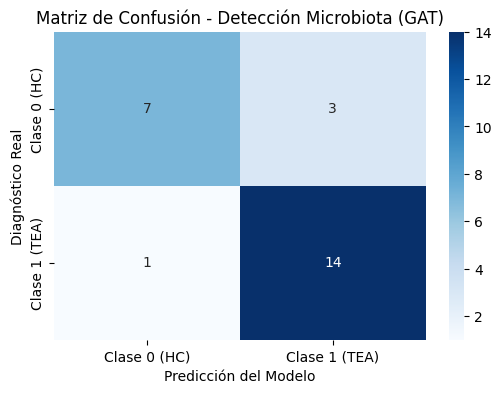

In [187]:
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARACIÓN DEL ENTORNO Y OPTIMIZADOR
# ==========================================
# Mandamos el modelo y los datos a la placa de video si estás usando el GPU de Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)
data = data.to(device)

# El optimizador AdamW suele dar excelentes resultados en topologías bioinformáticas
# lr = Learning Rate (tasa de aprendizaje). weight_decay evita el sobreajuste.
optimizador = optim.AdamW(modelo.parameters(), lr=0.005, weight_decay=1e-2)

# Función de pérdida para clasificación binaria
#criterio = nn.CrossEntropyLoss()
pesos_clases = torch.tensor([1.21, 0.85]).to(device)
criterio = nn.CrossEntropyLoss(weight=pesos_clases)
# ==========================================
# 2. BUCLE DE ENTRENAMIENTO (TRAINING LOOP)
# ==========================================
epocas = 100
print("--- INICIANDO ENTRENAMIENTO ---")

for epoca in range(epocas):
    modelo.train()            # Habilita el Dropout y el modo de aprendizaje
    optimizador.zero_grad()   # Limpia los gradientes de la vuelta anterior

    # 1. Forward Pass: La red recorre todo el grafo (pacientes y bacterias)
    salida = modelo(data.x_dict, data.edge_index_dict, data.edge_attr_dict)

    # 2. Aislar predicciones y etiquetas
    predicciones = salida
    etiquetas_reales = data['paciente'].y
    mascara_train = data['paciente'].train_mask

    # 3. Cálculo de Error (Loss): Solo evaluamos a los pacientes de entrenamiento
    loss = criterio(predicciones[mascara_train], etiquetas_reales[mascara_train])

    # 4. Backpropagation: Actualización de los pesos de la GAT
    loss.backward()
    optimizador.step()

    # Imprimir el progreso
    if (epoca + 1) % 20 == 0:
        print(f'Época {epoca+1:03d} | Pérdida (Loss): {loss.item():.4f}')

# ==========================================
# 3. EVALUACIÓN (TESTING) Y MÉTRICAS
# ==========================================
print("\n--- INICIANDO EVALUACIÓN EN CONJUNTO DE PRUEBA ---")
modelo.eval() # Apagamos el Dropout para tener predicciones determinísticas

with torch.no_grad():
    # Volvemos a pasar el grafo completo, pero sin calcular gradientes
    salida_final = modelo(data.x_dict, data.edge_index_dict, data.edge_attr_dict)

    # argmax(dim=1) elige la clase con la probabilidad matemática más alta
    clases_predichas = salida_final.argmax(dim=1)

# Filtramos aislando exclusivamente a los pacientes del 20% oculto
mascara_test = data['paciente'].test_mask
y_real = data['paciente'].y[mascara_test].cpu().numpy()
y_predicho = clases_predichas[mascara_test].cpu().numpy()

# ==========================================
# 4. REPORTE VISUAL (MATRIZ DE CONFUSIÓN)
# ==========================================
# Corregimos el orden de los nombres de las clases para que coincidan con las etiquetas reales (0=HC, 1=TEA)
nombres_clases = ['Clase 0 (HC)', 'Clase 1 (TEA)']

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_real, y_predicho, target_names=nombres_clases))

# Dibujar la matriz térmica
matriz = confusion_matrix(y_real, y_predicho)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Detección Microbiota (GAT)')
plt.ylabel('Diagnóstico Real')
plt.xlabel('Predicción del Modelo')
plt.show()

In [189]:
import pandas as pd
import torch

print("--- INICIANDO EXPLICABILIDAD (EXTRACCIÓN DE ATENCIÓN) ---")

# 1. Elegir un paciente para analizar (como antes)
mascara_test = data['paciente'].test_mask
pacientes_test_idx = mascara_test.nonzero(as_tuple=True)[0]

# Tomamos el primer paciente de test como ejemplo
paciente_objetivo = pacientes_test_idx[0].item()
diagnostico_real = data['paciente'].y[paciente_objetivo].item()
print(f"Analizando Paciente ID Interno: {paciente_objetivo} | Diagnóstico real: {diagnostico_real}")

# =========================================================
# EL TRUCO DE LA ATENCIÓN: Extraer los pesos directamente
# =========================================================
# En lugar de usar GNNExplainer, le pedimos a tu capa GATConv
# que nos devuelva exactamente cuánta "atención" (importancia)
# le prestó a cada conexión durante el último salto.

tipo_arista = ('paciente', 'abundancia_de', 'bacteria')
conexiones = data.edge_index_dict[tipo_arista]

modelo.eval()
with torch.no_grad():
    # Accedemos a la capa específica dentro del HeteroConv
    capa_gat = modelo.conv1.convs[tipo_arista]

    # x_tupla: (características de origen, características de destino)
    x_tupla = (data.x_dict['paciente'], data.x_dict['bacteria'])

    # Hacemos una pasada por esta única capa pidiéndole que DEVUELVA LOS PESOS DE ATENCIÓN (return_attention_weights=True)
    out, (edge_index_out, alpha) = capa_gat(
        x_tupla,
        conexiones,
        edge_attr=data.edge_attr_dict[tipo_arista],
        return_attention_weights=True
    )

# 'alpha' contiene la importancia (de 0.0 a 1.0) que la GAT le dio a CADA arista
# Promediamos si hubieras usado múltiples heads (como usaste heads=1, no cambia nada, pero es buena práctica)
if alpha.dim() > 1:
    importancia_aristas = alpha.mean(dim=-1).squeeze()
else:
    importancia_aristas = alpha.squeeze()


# =========================================================
# FILTRAR PARA EL PACIENTE OBJETIVO (Mismo código de antes)
# =========================================================
# La fila 0 de las conexiones son los pacientes, la fila 1 son las bacterias
aristas_del_paciente = (conexiones[0] == paciente_objetivo)
bacterias_conectadas = conexiones[1][aristas_del_paciente]
importancia_bacterias = importancia_aristas[aristas_del_paciente]

# Armar el ranking con las bacterias más importantes
ranking = pd.DataFrame({
    'bacteria_idx_interno': bacterias_conectadas.cpu().numpy(),
    'importancia_GNN': importancia_bacterias.cpu().numpy()
})

# Ordenamos de mayor a menor importancia
ranking = ranking.sort_values(by='importancia_GNN', ascending=False)

# Escalar para que el máximo sea 1.0 (facilita la visualización luego)
if ranking['importancia_GNN'].max() > 0:
    ranking['importancia_GNN'] = ranking['importancia_GNN'] / ranking['importancia_GNN'].max()

nombres_clases = ['Clase 0 (HC)', 'Clase 1 (TEA)']
print(f"\nTOP 5 BACTERIAS MÁS IMPORTANTES PARA DIAGNOSTICAR {nombres_clases[diagnostico_real]}:")
print(ranking.head(5).to_string(index=False))

--- INICIANDO EXPLICABILIDAD (EXTRACCIÓN DE ATENCIÓN) ---
Analizando Paciente ID Interno: 7 | Diagnóstico real: 0

TOP 5 BACTERIAS MÁS IMPORTANTES PARA DIAGNOSTICAR Clase 0 (HC):
 bacteria_idx_interno  importancia_GNN
                  140         1.000000
                  138         0.758331
                  125         0.361398
                  134         0.329040
                  120         0.293262


In [195]:
import pandas as pd
import torch

print("--- INICIANDO EXPLICABILIDAD (EXTRACCIÓN DE ATENCIÓN) ---")

# 1. Elegir un paciente para analizar (como antes)
mascara_test = data['paciente'].test_mask
pacientes_test_idx = mascara_test.nonzero(as_tuple=True)[0]

# Tomamos el primer paciente de test como ejemplo
paciente_objetivo = pacientes_test_idx[10].item()
diagnostico_real = data['paciente'].y[paciente_objetivo].item()
print(f"Analizando Paciente ID Interno: {paciente_objetivo} | Diagnóstico real: {diagnostico_real}")

# =========================================================
# EL TRUCO DE LA ATENCIÓN: Extraer los pesos directamente
# =========================================================
# En lugar de usar GNNExplainer, le pedimos a tu capa GATConv
# que nos devuelva exactamente cuánta "atención" (importancia)
# le prestó a cada conexión durante el último salto.

tipo_arista = ('paciente', 'abundancia_de', 'bacteria')
conexiones = data.edge_index_dict[tipo_arista]

modelo.eval()
with torch.no_grad():
    # Accedemos a la capa específica dentro del HeteroConv
    capa_gat = modelo.conv1.convs[tipo_arista]

    # x_tupla: (características de origen, características de destino)
    x_tupla = (data.x_dict['paciente'], data.x_dict['bacteria'])

    # Hacemos una pasada por esta única capa pidiéndole que DEVUELVA LOS PESOS DE ATENCIÓN (return_attention_weights=True)
    out, (edge_index_out, alpha) = capa_gat(
        x_tupla,
        conexiones,
        edge_attr=data.edge_attr_dict[tipo_arista],
        return_attention_weights=True
    )

# 'alpha' contiene la importancia (de 0.0 a 1.0) que la GAT le dio a CADA arista
# Promediamos si hubieras usado múltiples heads (como usaste heads=1, no cambia nada, pero es buena práctica)
if alpha.dim() > 1:
    importancia_aristas = alpha.mean(dim=-1).squeeze()
else:
    importancia_aristas = alpha.squeeze()


# =========================================================
# FILTRAR PARA EL PACIENTE OBJETIVO (Mismo código de antes)
# =========================================================
# La fila 0 de las conexiones son los pacientes, la fila 1 son las bacterias
aristas_del_paciente = (conexiones[0] == paciente_objetivo)
bacterias_conectadas = conexiones[1][aristas_del_paciente]
importancia_bacterias = importancia_aristas[aristas_del_paciente]

# Armar el ranking con las bacterias más importantes
ranking = pd.DataFrame({
    'bacteria_idx_interno': bacterias_conectadas.cpu().numpy(),
    'importancia_GNN': importancia_bacterias.cpu().numpy()
})

# Ordenamos de mayor a menor importancia
ranking = ranking.sort_values(by='importancia_GNN', ascending=False)

# Escalar para que el máximo sea 1.0 (facilita la visualización luego)
if ranking['importancia_GNN'].max() > 0:
    ranking['importancia_GNN'] = ranking['importancia_GNN'] / ranking['importancia_GNN'].max()

nombres_clases = ['Clase 0 (HC)', 'Clase 1 (TEA)']
print(f"\nTOP 5 BACTERIAS MÁS IMPORTANTES PARA DIAGNOSTICAR {nombres_clases[diagnostico_real]}:")
print(ranking.head(5).to_string(index=False))

--- INICIANDO EXPLICABILIDAD (EXTRACCIÓN DE ATENCIÓN) ---
Analizando Paciente ID Interno: 36 | Diagnóstico real: 1

TOP 5 BACTERIAS MÁS IMPORTANTES PARA DIAGNOSTICAR Clase 1 (TEA):
 bacteria_idx_interno  importancia_GNN
                  314         1.000000
                  313         1.000000
                  315         1.000000
                  282         0.334175
                  159         0.252294
